# Trabalho Prático 1: Compressão de Imagens

## Alunos: 

- Felipe Eduardo dos Santos - 2017021223
- Renan Antunes Braga Bomtempo - 2018048524

# Introdução

Falar o que a gente implementou e das decisões que 
tomamos sobre a medição de tamanho de arquivo etc

# Dependências

In [92]:
%matplotlib inline
import cv2
import io
import os
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy import fftpack
import matplotlib.image as mpimg

np.set_printoptions(precision=1, suppress=True)

# Funções Auxiliares

In [93]:
def get_2D_dct(img):
    """ Get 2D Cosine Transform of Image
    """
    return fftpack.dct(fftpack.dct(img.T, norm='ortho').T, norm='ortho')

def get_2d_idct(coefficients):
    """ Get 2D Inverse Cosine Transform of Image
    """
    return fftpack.idct(fftpack.idct(coefficients.T, norm='ortho').T, norm='ortho')

# Calcula o rmse
def rmse(predictions, targets):
    return np.sqrt(((predictions - targets) ** 2).mean())

# Calcula o psnr
def psnr(predictions, targets):
    rmsev = rmse(predictions, targets)
    return 20 * np.log10(255/rmsev)

# Retorna o tamanho de um arquivo em bytes
def file_size(file_path):
    if os.path.isfile(file_path):
        file_info = os.stat(file_path)
        return file_info.st_size
    
# Printa a imagem em tons de cinza
def print_gimage(img, window_name):
    #plt.subplot(121)
    plt.imshow(img, cmap = 'gray', clim=(0, 255))
    plt.title(window_name+" - "+str(img.shape)), plt.xticks([]), plt.yticks([])
    plt.show()

# Salva um numpy.ndarray, com elementos do tipo numpy.uint8
# em um arquivo, seja .txt ou .bin
def img_to_file(img,output_name,separator=""):
    file = open(output_name, "w")
    img.tofile(file,sep=separator)
    file.close()
    
# De um arquivo txt ou bin, lê um numpy.ndarray de dimenções
# shape(tupla)
def file_to_img(input_name,shape,separator=""):
    file = open(input_name,"r")
    img = np.fromfile(file,dtype = np.uint8,sep=separator)
    img = img2.reshape(shape)
    file.close()
    return img

# Abrindo a Imagem

Atribua a variavel "input_img_name" o nome da imagem a ser comprimida

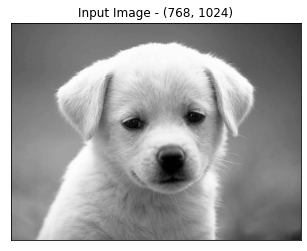

In [94]:
# Nome do arquivo de imagem a ser comprimida
input_img_name = "6.pgm"

# Carrega a imagem como um numpy.ndarray, com elementos do tipo numpy.uint8
img = cv2.imread(input_img_name,0)

# Mostra imagem que foi carregada
print_gimage(img,'Input Image')

# Compressão

### Transfomada

Aplicamos a DCT em blocos 8x8 da imagem

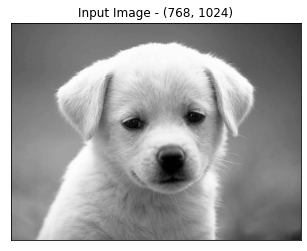

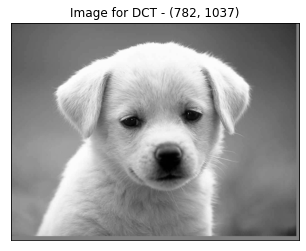

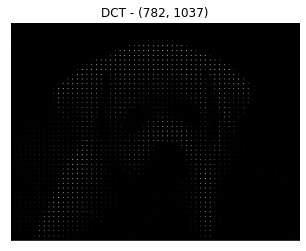

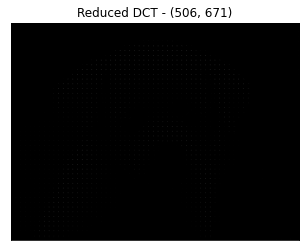

In [95]:
# Parâmetros da transformada
step    = 17     # Tamanho do bloco DCT
sv_step = 11     # Tamanho do bloco a ser salvo
dif     = step - sv_step

# Tamanho da imagem original
orig_size = img.shape

# Tamanho da DCT, aplicando padding se necessário
dct_size = (orig_size[0]+(step-(orig_size[0]%step))%step,
            orig_size[1]+(step-(orig_size[1]%step))%step)

# Tamanho da DCT reduzida
redu_size = (dct_size[0]-(dif*dct_size[0]//step),
             dct_size[1]-(dif*dct_size[1]//step))

# Matriz da DCT completa
DCT = np.zeros(dct_size, dtype=np.float)    

# Matriz da DCT apenas com os valores relevantes
reduced_DCT = np.zeros(redu_size, dtype=np.float)

# Imagem em que a DCT será aplicada
dct_img = np.zeros(dct_size, dtype=np.float)
dct_img[:orig_size[0],:orig_size[1]] = (img.astype(float))-128

# Executa a DCT
for y in range(0,dct_size[0],step):
    for x in range(0,dct_size[1],step):
        dct_step = get_2D_dct(dct_img[y:y+step, x:x+step])
        # DCT completa
        DCT[y:y+step, x:x+step] = dct_step
        # DCT reduzida
        reduced_DCT[y*sv_step//step:y*sv_step//step+sv_step, 
                    x*sv_step//step:x*sv_step//step+sv_step] = dct_step[:sv_step,:sv_step]  
        
# Aplica quantização na matriz reduzida da DCT
Q = np.max(np.absolute(reduced_DCT))/128 #Valor de quantização
reduced_DCT = reduced_DCT/Q

# Converte a matriz para inteiro de 8bits para armazenamento
# (o que serve como maneira de arrendondar os valores da transormada)
reduced_DCT = reduced_DCT.astype(np.int8)

# Visualização dos resultados

print_gimage(img,"Input Image")
print_gimage(dct_img+128, "Image for DCT")
print_gimage(DCT,"DCT")
print_gimage(reduced_DCT,"Reduced DCT")

### Codificação

Huffman? ou aquela do erro preditivo, que parece ser legal

### Resultado da compressão

Salvar no arquivo e comparar o tamanho com a imagem original

In [96]:
img_to_file(img,"original")
img_to_file(reduced_DCT,"compressed")

print("Compressão de ",(100-(file_size("compressed")/file_size("original"))*100), "%")

Compressão de  56.827036539713546 %


# Decompressão

### Decodificação

Ler do arquivo e decodificar pra ter os coeficientes da transformada de volta

### Transformada Inversa

Com os coeficientes decodificados, aplicar a transformada inversa

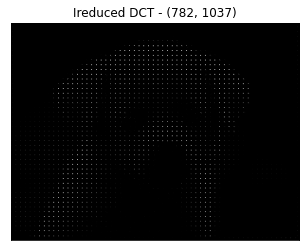

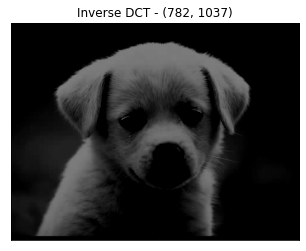

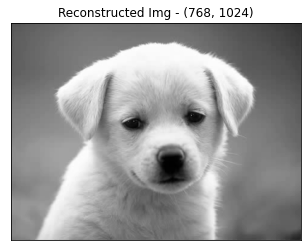

In [97]:
Ireduced_DCT = np.zeros(dct_size, dtype=np.float)
IDCT = np.zeros(dct_size, dtype=np.float)
rec_img = np.zeros(orig_size, dtype=np.float)

# Extendendo a imagem para o tamanho original
for y in range(0,redu_size[0],sv_step):
    for x in range(0,redu_size[1],sv_step):
        block = np.zeros((step,step),dtype=np.float)
        block[:sv_step, :sv_step] = reduced_DCT[y:y+sv_step, x:x+sv_step]
        Ireduced_DCT[y+(dif*y//sv_step):y+(dif*y//sv_step)+step,
                     x+(dif*x//sv_step):x+(dif*x//sv_step)+step] = block

# Reverte a quatização
Ireduced_DCT = Q*Ireduced_DCT

# Transformada inversa
for y in range(0,dct_size[0],step):
    for x in range(0,dct_size[1],step):
        idct = get_2d_idct(Ireduced_DCT[y:y+step, x:x+step])
        IDCT[y:y+step, x:x+step] = idct

# Imagem reconstruida
rec_img = IDCT[:orig_size[0], :orig_size[1]]+128

print_gimage(Ireduced_DCT,"Ireduced DCT")
print_gimage(IDCT,"Inverse DCT")
print_gimage(rec_img, "Reconstructed Img")

mpimg.imsave("original.png", img, 0, 255, cmap='gray')
mpimg.imsave(("{0}_IDCT_{1}x{1}-{2}.png".format(input_img_name,step, sv_step)), rec_img, 0, 255, cmap='gray')

# Analise de resultados

Printar o PSNR e falar algo sobre nosso resultados

In [98]:
print("PSNR foi de:",psnr(img,rec_img))

PSNR foi de: 39.498622920554276
